# RL First Notebook: Imports, Environment, Q-table

This notebook is a learning scaffold. The goal is to understand how the Python libraries are imported and how a tiny tabular RL setup is organized before you complete the training loop.

## 1. Imports

Python libraries are imported at the top of the notebook so later cells can use them.

- `numpy` is imported as `np` because most examples use that short name.
- `matplotlib.pyplot` is imported as `plt` for plotting rewards later.
- `gymnasium` is optional. If it is not installed, this notebook still works with a tiny hand-made gridworld.

In [38]:
import numpy as np
import matplotlib.pyplot as plt

print("NumPy version:", np.__version__)

NumPy version: 2.4.4


## 2. Optional RL Library Check

`gymnasium` gives ready-made RL environments such as FrozenLake. Do not get stuck here. If the import fails, continue with the simple gridworld below.

In [39]:
try:
    import gymnasium as gym
    GYM_AVAILABLE = True
    print("gymnasium is available")
except ImportError:
    gym = None
    GYM_AVAILABLE = False
    print("gymnasium is not installed. Use the tiny gridworld path instead.")

gymnasium is available


## 3. What An Environment Gives You

An RL environment needs this basic interaction:

1. You start in a `state`.
2. You choose an `action`.
3. The environment returns `next_state`, `reward`, and `done`.

That is the main difference from supervised learning. There is no fixed label for every row. The agent learns from reward feedback.

In [40]:
GRID_SIZE = 4
NUM_STATES = 16

START = (0, 0)
GOAL = (3, 3)
HOLES = {(1, 1), (2, 1)}

ACTIONS = {
    0: (-1, 0),  # up
    1: (0, 1),   # right
    2: (1, 0),   # down
    3: (0, -1),  # left
}
NUM_ACTIONS = len(ACTIONS)

In [41]:
def to_state_id(state):
    row, col = state
    return row * GRID_SIZE + col

def from_state_id(state_id):
    return divmod(state_id, GRID_SIZE)

In [42]:
def step(state, action, goal):
    """Return next_state, reward, done for the deterministic 4x4 gridworld."""
    move = ACTIONS[action]
    row, col = state
    d_row, d_col = move
    target_pos = (row + d_row, col + d_col)

    # Moving into a wall leaves the agent in the same state.
    if (
        target_pos[0] < 0
        or target_pos[0] >= GRID_SIZE
        or target_pos[1] < 0
        or target_pos[1] >= GRID_SIZE
    ):
        target_pos = state

    reward = 1 if target_pos == goal else 0
    done = target_pos == goal or target_pos in HOLES
    return target_pos, reward, done

## 4. Q-table

`Q[state_id, action]` means: how good it currently seems to take this action from this state.

The environment uses `(row, col)` coordinates, but the Q-table uses integer state IDs:

```text
state_id = row * 4 + col
```

For 16 states and 4 actions, the table shape is `(16, 4)`.

In [43]:
Q = np.zeros((NUM_STATES, NUM_ACTIONS))

print("Q-table shape:", Q.shape)
Q

Q-table shape: (16, 4)


array([[0., 0., 0., 0.],
       [0., 0., 0., 0.],
       [0., 0., 0., 0.],
       [0., 0., 0., 0.],
       [0., 0., 0., 0.],
       [0., 0., 0., 0.],
       [0., 0., 0., 0.],
       [0., 0., 0., 0.],
       [0., 0., 0., 0.],
       [0., 0., 0., 0.],
       [0., 0., 0., 0.],
       [0., 0., 0., 0.],
       [0., 0., 0., 0.],
       [0., 0., 0., 0.],
       [0., 0., 0., 0.],
       [0., 0., 0., 0.]])

## 5. Hyperparameters

These are just settings for learning:

- `learning_rate`: how strongly each new experience changes the table.
- `discount`: how much future reward matters.
- `epsilon`: how often the agent explores instead of taking the best-known action.

In [44]:
np.random.seed(0)

learning_rate = 0.5
discount = 0.95
epsilon = 0.6
episodes = 1000
max_steps_per_episode = 20

## 6. Action Choice Scaffold

This function chooses an action. Sometimes it explores randomly; otherwise it uses the current Q-table.

Read this carefully before the training loop. This is one of the main places where RL differs from normal prediction.

In [45]:
def choose_action(state, epsilon):
    state_id = to_state_id(state)

    if np.random.random() < epsilon:
        return np.random.randint(NUM_ACTIONS)

    return int(np.argmax(Q[state_id]))

for _ in range(5):
    print(choose_action(START, epsilon=0.5))

0
0
0
0
1


## 7. Training Loop TODO

Now complete the Q-learning loop yourself.

Inside each episode:

1. Start from `START`, a `(row, col)` coordinate.
2. Choose an action using the current coordinate state.
3. Call `step(state, action, GOAL)`.
4. Convert coordinate states to `state_id` only when indexing the Q-table.
5. Compute the target: `reward + discount * best future Q-value`.
6. Move `Q[state_id, action]` toward that target.
7. Move to `next_state`.
8. Stop if `done` is true.

The update shape is:

```text
Q[state_id, action] = old + learning_rate * (target - old)
```

If `done` is true, the future value is `0` because the episode has ended.

## 7a. Explicit MDP Contract

| MDP component | Fixed 4x4 gridworld value |
| --- | --- |
| State | `(row, col)` plus `state_id = row * 4 + col` |
| Action | `0=up`, `1=right`, `2=down`, `3=left` |
| Reward | `+1` at `(3, 3)`, `0` otherwise |
| Transition | deterministic movement, wall keeps same state |
| Terminal condition | goal `(3, 3)` or holes `(1, 1)`, `(2, 1)` |
| Discount factor | `gamma = 0.95` |

In [46]:
example_state = (0, 0)
example_action = 1  # right
example_next_state, example_reward, example_done = step(example_state, example_action, GOAL)

print("state:", example_state)
print("state_id:", to_state_id(example_state))
print("action:", example_action, ACTIONS[example_action])
print("next_state:", example_next_state)
print("next_state_id:", to_state_id(example_next_state))
print("reward:", example_reward)
print("done:", example_done)

state: (0, 0)
state_id: 0
action: 1 (0, 1)
next_state: (0, 1)
next_state_id: 1
reward: 0
done: False


In [47]:
episode_rewards = []
Q = np.zeros((NUM_STATES, NUM_ACTIONS))

# Q-learning loop.
# Read it as: choose action -> observe result -> update Q-table -> move state.
for episode in range(episodes):
    state = START
    total_reward = 0

    for t in range(max_steps_per_episode):
        action = choose_action(state, epsilon)
        next_state, reward, done = step(state, action, GOAL)

        state_id = to_state_id(state)
        next_state_id = to_state_id(next_state)

        old_value = Q[state_id, action]
        print(old_value)
        best_future_value = 0 if done else np.max(Q[next_state_id])
        target = reward + discount * best_future_value

        Q[state_id, action] = old_value + learning_rate * (target - old_value)

        state = next_state
        total_reward += reward

        if done:
            break

    episode_rewards.append(total_reward)

print("Final Q-table:")
print(Q)
print("Episode rewards:", episode_rewards)

0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0


In [48]:
state = (3, 2)
action = 1  # right
next_state = (3, 3)
reward = 1
done = True

state_id = to_state_id(state)
next_state_id = to_state_id(next_state)

old_q = Q[state_id, action]
best_next_q = 0.0 if done else np.max(Q[next_state_id])
target = reward + discount * best_next_q
td_error = target - old_q
new_q = old_q + learning_rate * td_error

print("state:", state, "state_id:", state_id)
print("action:", action, ACTIONS[action])
print("next_state:", next_state, "next_state_id:", next_state_id)
print("old_q:", old_q)
print("best_next_q:", best_next_q)
print("target:", target)
print("td_error:", td_error)
print("new_q:", new_q)

state: (3, 2) state_id: 14
action: 1 (0, 1)
next_state: (3, 3) next_state_id: 15
old_q: 1.0
best_next_q: 0.0
target: 1.0
td_error: 0.0
new_q: 1.0


Q-learning is TD learning because it updates after one step using reward plus an estimate of future value, instead of waiting for the full episode return.

## 8. Plot Rewards

After you complete the training loop, this plot should show whether the agent starts reaching the goal more often.

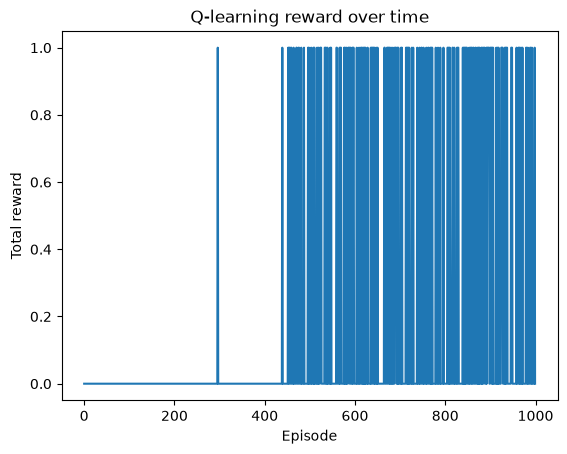

In [49]:
plt.plot(episode_rewards)
plt.xlabel("Episode")
plt.ylabel("Total reward")
plt.title("Q-learning reward over time")
plt.show()

## 9. Final Policy

After training, the best action for each Q-table row is `np.argmax(Q[state_id])`.

Use `from_state_id(state_id)` to translate the table row back into a `(row, col)` grid coordinate.

In [50]:
best_actions = np.argmax(Q, axis=1)

for state_id, action in enumerate(best_actions):
    state = from_state_id(state_id)
    print(f"state_id={state_id:2d} state={state} best_action={action} move={ACTIONS[action]}")

print("Q-table:")
print(Q)

state_id= 0 state=(0, 0) best_action=2 move=(1, 0)
state_id= 1 state=(0, 1) best_action=3 move=(0, -1)
state_id= 2 state=(0, 2) best_action=3 move=(0, -1)
state_id= 3 state=(0, 3) best_action=3 move=(0, -1)
state_id= 4 state=(1, 0) best_action=2 move=(1, 0)
state_id= 5 state=(1, 1) best_action=0 move=(-1, 0)
state_id= 6 state=(1, 2) best_action=0 move=(-1, 0)
state_id= 7 state=(1, 3) best_action=2 move=(1, 0)
state_id= 8 state=(2, 0) best_action=2 move=(1, 0)
state_id= 9 state=(2, 1) best_action=0 move=(-1, 0)
state_id=10 state=(2, 2) best_action=2 move=(1, 0)
state_id=11 state=(2, 3) best_action=2 move=(1, 0)
state_id=12 state=(3, 0) best_action=1 move=(0, 1)
state_id=13 state=(3, 1) best_action=1 move=(0, 1)
state_id=14 state=(3, 2) best_action=1 move=(0, 1)
state_id=15 state=(3, 3) best_action=0 move=(-1, 0)
Q-table:
[[0.73509189 0.6983373  0.77378094 0.73509189]
 [0.6983373  0.66342043 0.         0.73509189]
 [0.65699498 0.62721069 0.6184236  0.6983373 ]
 [0.55892248 0.48104856 0.4

Q-learning is TD learning because it updates after one step using reward plus an estimate of future value.

## 10. Concept Check

Fill this in after you finish the code:

| Concept | Your explanation |
| --- | --- |
| State | the position of the player |
| Action | the direction he picks |
| Reward | solving the maze |
| Q-value | |
| Exploration | moving randomly inside the maza |
| Q-learning vs A* | experimantal exploration vs maze solving algorithm|
| Q-learning vs minimax | experimental exploration vs 2-player adverserial maximization|